# Clase 8: Visualización y Análisis Exploratorio de Datos


**MDS7202: Laboratorio de Programación Científica para Ciencia de Datos**

Clase Basada en el Post [**The Art and Science of Data Visualization**](https://towardsdatascience.com/the-art-and-science-of-data-visualization-6f9d706d673e) de [Michael Mahoney](https://medium.com/@mike.mahoney.218)

In [ ]:
!uv pip install plotly statsmodels

## Objetivos de la Clase

1. Introducirlos a las visualizaciones de datos y sus principios. 
2. Entregar ejemplos de visualizaciones.
3. Introducirlos al uso de `plotly` para generar gráficos interactivos.

## Visualización de Datos


La visualización de datos es un área dedicada a representar gráficamente los datos con el objetivo de poder comunicar información de forma eficiente y sencilla.


En términos prácticos, es una función que mapea los datos a un gráfico. El mapeo determina entre otras cosas: 
    
- Elementos visuales que se mostrarán.
- Posición de los elementos.
- Color de los elementos.
- Forma y tamaño de los elementos.


El tipo de mapeo que creemos determinará qué tan entendible el gráfico será. Por ende, **es de suma importancia crear buenos mapeos**. 

Un gráfico "bonito/estético" está mucho más allá de formalidades matemáticas. Por ende, la visualización de datos es considerada tanto una ciencia como también un arte.

Si bien, la librería "por defecto" de graficado en python es `Matplotlib`, en este curso usaremos `plotly` como librería para generar las visualizaciones debido principalmente a sus interfaces y su interactividad.

### Los Principios

Según *The Art and Science of Data Visualization*, una buena visualización debe cumplir los siguientes principios:


1. **Un buen gráfico cuenta una historia.**

2. **Todo debe ser hecho de la forma más sencilla posible, pero no debe ser simple.**

3. **Se debe usar la herramienta correcta para el trabajo a resolver.**

4. **La tinta es barata, los electrones aún más.**



> Nota: Lo simple es llano, fácil, falto de profundidad. Lo sencillo es certero, esencial, preciso, sobrio, escueto, claro y puede también ser modesto. Fuente: [Diferencia entre simple y sencillo](https://elpais.com/elpais/2020/01/14/del_tirador_a_la_ciudad/1579025106_976460.html).


Cada uno de estos los veremos a continuación

## Pinguinos 🐧


**Palmer Archipelago (Antarctica) penguin data**: 


*Data were collected and made available by Dr. Kristen Gorman and the Palmer Station, Antarctica LTER, a member of the Long Term Ecological Research Network.*

https://github.com/allisonhorst/palmerpenguins

![Pinguinos](https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/man/figures/lter_penguins.png)


    
    
    

### Atributos
 
- `culmen_length_mm`: Largo del culmen (vértice o borde superior de la mandíbula)  (mm).
- `culmen_depth_mm`: Alto del culmen (vértice o borde superior de la mandíbula) (mm).
- `flipper_length_mm`: Longitud de las aletas (mm).
- `body_mass_g`: Masa corporal (g).
- `island`: Isla de origen (Dream, Torgersen, or Biscoe) en el archipiélago de Palmer (Antarctica).
- `sex`: Sexo del pinguino.
- `species`: Especie del pinguino (Chinstrap, Adélie, or Gentoo)
    
![Detalle Variables](https://allisonhorst.github.io/palmerpenguins/reference/figures/culmen_depth.png)
    
<center>Créditos a Allison Horst por sus excelentes ilustraciones https://github.com/allisonhorst </center>    
    


In [ ]:
import pandas as pd

df = pd.read_csv(
    "https://raw.githubusercontent.com/MDS7202/MDS7202/main/recursos/2023-01/12-Visualizaciones/penguins.csv"
)
df = df.dropna()
df


---

## 1.- Un Buen Gráfico Cuenta Una Historia


Cuando construimos un gráfico, es importante entender para qué lo estamos construyendo.
Para esto, es preciso pensar por qué y para qué lo estamos creando.



### ¿Por qué creamos los gráficos?

Comúnmente puede caer en dos categorías: 

1. **Gráficos exploratorios**, los cuales se enfocan en identificar patrones en los datos.
2. **Gráficos explicativos**, los cuales se enfocan en explicar los patrones encontrados en los datos.

In [ ]:
import plotly.express as px

#### Gráficos Exploratorios

Los gráficos exploratorios son comúnmente gráficos muy simples de nuestros datos. Su objetivo es **identificar patrones y cómo ocurren en nuestros datos**.


> **Pregunta ❓**: ¿Dado el datasets de los pinguinos, que sería interesante explorar?

In [ ]:
df.head()


Tomemos por ejemplo, el siguiente gráfico de dispersión en donde relacionamos el largo de la aleta con la masa corporal:

In [ ]:
px.scatter(
    df,
    x="flipper_length_mm",
    y="body_mass_g",
)


Para este caso, podemos observar claramente que existe un patrón entre ambas variables: a medida que `flipper_length_mm` aumenta, también lo hace `body_mass_g`. 

**El objetivo final (para nosotros) de esta visualización sería entonces entender cómo es esta relación.**

En el siguiente ejemplo se muestra la relación entre el largo y profundidad del culmen:

In [ ]:
px.scatter(
    df,
    x="culmen_length_mm",
    y="culmen_depth_mm",
)


A diferencia del gráfico anterior, en esta figura no podemos inferir ninguna relación a simple vista.

#### Gráficos Explicativos

Este tipo de gráficos intenta incluir **explicaciones del por qué suceden los patrones**.

In [ ]:
fig = px.scatter(
    df,
    x="flipper_length_mm",
    y="body_mass_g",
    trendline="ols",
    title=(
        "Relationship between Body Mass and Flipper Length in Penguins"
        "<br><sup>A linear relationship between variables is shown "
        "through linear regression (R² = 0.759).</sup></br>"
    ),
)
fig.update_layout(xaxis_title="Flipper length (mm)", yaxis_title="Body mass (g)")
fig.show()

> **Pregunta ❓**: Entonces, cuál es la diferencia entre el gráfico exploratorio y el explicativo?

Noten que la diferencia entre el gráfico exploratorio y el explicativo no es lo pulido que es este, si no que en este caso se intenta incluir una explicación a los patrones detectados.

### ¿Cómo contamos la Historia?

Obviamente existe una infinidad de posibles combinaciones de gráficos y sus elementos para representar visualmente un objeto. La idea es que podamos seleccionar la mejor.
Podemos utilizar para esto dos criterios:


1. **Expresividad:** Un conjunto de hechos es expresable en un lenguaje visual si las visualizaciones en el lenguaje expresan todos los hechos del conjunto de datos y sólo los hechos de los datos. 

2. **Eficacia:** Una visualización es más eficaz que otra si la información transmitida por una visualización se percibe más fácilmente que la información de la otra visualización.


...que en términos más sencillos se podrían traducir en: 

1. **Solo decir la verdad y nada más que la verdad (no se debe mentir ni tampoco mentir por omisión)**
2. **Utilizar solo los elementos que la gente pueda entender mejor (donde mejor = más rápido y/o más preciso).**



---

## 2.- Todo debe ser hecho de la forma más sencilla posible, pero no debe ser simple

El gráfico más simple es el gráfico de dispersión en 2 dimensiones, el cual representa en 2D un par de variables de nuestro dataset.

In [ ]:
fig = px.scatter(df, x="flipper_length_mm", y="body_mass_g")
fig.show()

En esta figura, tanto el eje X (largo de la aleta) como el eje Y (masa) tienen una escala y cada punto recae sobre una combinación de una posición en los ejes. Esta es toda la información que podemos representar hasta el momento.

> **Pregunta ❓**: ¿Cuál es el problema de este tipo de gráficos?

> **Pregunta ❓**: Entonces, ¿Cómo podríamos visualizar más variables?

In [ ]:
# Recordemos el dataset con el que estamos trabajando
df.head()

Una posible solución sería agregar más dimensiones a nuestra visualización:

In [ ]:
fig = px.scatter_3d(df, x="flipper_length_mm", y="body_mass_g", z="island")
fig.show()

> **⚠️ Advertencia:** En este gráfico, `island` es una variable **categórica** sin orden intrínseco. Usarla en el eje Z de un scatter 3D puede inducir la percepción errónea de que existe una magnitud o gradiente entre las islas. Para variables categóricas, se recomienda usar `color` o `symbol` en lugar de un eje continuo.

> **Pregunta ❓**: ¿Cuál es el problema de los gráficos en 3D? ¿Cómo podríamos seguir agregando variables?

Sin embargo, esto puede provocar que incremente la dificultad para comprender lo que se comunica, sobre todo si se representa una variable con mayor desorden:

In [ ]:
fig = px.scatter_3d(df, x="flipper_length_mm", y="body_mass_g", z="culmen_length_mm")
fig.show()

Y el mayor problema: No podemos agregar otra dimensión más.


> **Pregunta ❓**: Entonces, nuevamente viene la pregunta: ¿Cómo podemos visualizar más variables?

### Aesthetics o Parámetros de la Figura

> *Estética según wikipedia: La estética es la rama de la filosofía que estudia la esencia y la percepción de la belleza y el arte.*


No solo disponemos de la posición de los puntos sobre sus ejes para poder representar más de dos variables datos, si no que además contamos con elementos extra como: 




 1. Posición
 2. Color
 3. Forma
 4. Tamaño 
 
Cada uno de estos parámetros y sus combinaciones nos permitirán agregar nuevas variables a nuestros gráficos. 

### 1. Posición

La distancia entre los valores del eje X o Y representa que tan larga la variable es. La gente tiende a considerar que mientras mas lejos está un punto, más grande y extremo es su valor. Veamos esto a través de un sencillo ejemplo en donde generamos un punto que está fuera de los patrones:

In [ ]:
# solo como ejemplo, modificaremos la última medición como un caso extremo
df_ = df.copy()
df_.loc[df_.index[-1], "flipper_length_mm"] = 240
df_.loc[df_.index[-1], "body_mass_g"] = 6650

fig = px.scatter(
    df_,
    x="flipper_length_mm",
    y="body_mass_g",
)
fig.show()

Si bien, se ve a simple vista que este punto está fuera de lo esperado, puede en términos prácticos, no sea realmente así. Para mostrar esto, crearemos el mismo gráfico con el eje X partiendo desde 0.

In [ ]:
fig = px.scatter(
    df_, x="flipper_length_mm", y="body_mass_g", range_x=(0, 300), range_y=(0, 6500)
)
fig.show()

Aquí pueden notar que en la práctica, no está tan lejos como pensábamos en un inicio respecto al 0. 



Otro ejemplo para gráficos con variables categóricas.


<br>
<div align='center'/>

<img src='https://raw.githubusercontent.com/MDS7202/MDS7202/main/recursos/2023-01/12-Visualizaciones/grafico_charcha.jpg' />
</div>

> **Pregunta ❓**: ¿Qué hay de malo con este gráfico?

In [ ]:
import plotly.graph_objects as go

fig = go.Figure(
    data=[
        go.Bar(
            x=[2010, 2013, 2016],
            y=[30.7, 22.8, 27.3],
            marker_color=["red", "blue", "red"],
        )
    ]
)
fig.show()

In [ ]:
fig.update_yaxes(range=[20, 32])
fig.show()

#### Para Concluir

La moraleja de esta sección es que al momento de diseñar una visualización se debe tener en cuenta el rango/escala de las variables que se están graficando. Una escala distinta puede llevar a gráficos con interpretaciones totalmente distintas.

### Color


Si bien, la sección anterior nos dio una gran idea de lo cuidadosos que hay que ser al tratar con los ejes y la posición de los datos, aún no sabemos cómo incluir una nueva variable dentro de las visualizaciones.

**Spoiler**: Podemos lograrlo usando colores.


Como ejemplo, incluyamos la isla en donde se tomó la medición de cada pinguino:

In [ ]:
# Recordemos el dataset con el que estamos trabajando
df.head()

In [ ]:
fig = px.scatter(
    df,
    x="flipper_length_mm",
    y="body_mass_g",
    color="island",
)

fig.show()


Noten que en este caso el color representa una variable categórica, en donde cada isla tomó un color en particular.


> **Pregunta ❓**: Entonces, ¿cómo represento una variable numérica al trabajar con colores?

#### Luminiscencia

Sin embargo, si fuese una variable continua, estos colores nada nos dirían con respecto a la magnitud de esta nueva variable. 

Para poder representar podemos usar paletas de colores continuas, en donde se utiliza un conjunto de colores con distinta **luminiscencia** (que tanto brilla un color) de tal forma que algunos colores indican bajo valor y otros alto.

En este caso, el gráfico incluye una variable que no está representada por los puntos del gráfico de dispersión.

In [ ]:
fig = px.scatter(
    df,
    x="flipper_length_mm",
    y="body_mass_g",
    color="culmen_length_mm",
    color_continuous_scale="viridis_r",
)


fig.show()


In [ ]:
# un vistazo de todas las paletas de colores continuas disponibles

fig = px.colors.sequential.swatches_continuous()
fig.show()

Consideremos ahora el siguiente ejemplo, en donde generamos 15 bins para `body_mass_g` y después los graficamos

In [ ]:
df_ = df.copy()
df_.loc[:, "body_mass_g_bins"] = pd.cut(
    df.loc[:, "body_mass_g"], 15, labels=[f"Bin {i + 1}" for i in range(0, 15)]
)

fig = px.scatter(
    df_,
    x="flipper_length_mm",
    y="body_mass_g",
    color="body_mass_g_bins",
    color_continuous_scale="viridis_r",
)


fig.show()


> **Pregunta❓**: ¿Cuál es el problema en este gráfico?

**Cuidado con los colores!**

Tiende a pasar que se sobreutilizan los colores. Esto induce finalmente a que el color tienda a confundir más que a ayudar.

> **Pregunta ❓** ¿Qué precauciones debemos tener al usar colores en nuestras visualizaciones?


Relacionado: [viridis](https://cran.r-project.org/web/packages/viridis/vignettes/intro-to-viridis.html)

Existen anomalías visuales que afectan la percepción de ciertos colores. Entre estas, se encuentran la `deuteranomalía` y la `protanomalía`, condiciones en las que las personas tienen dificultades para distinguir los colores verde y rojo, respectivamente. Por otro lado, la `tritanomalía` es otra anomalía visual donde los individuos enfrentan problemas para identificar correctamente los colores azul y amarillo.

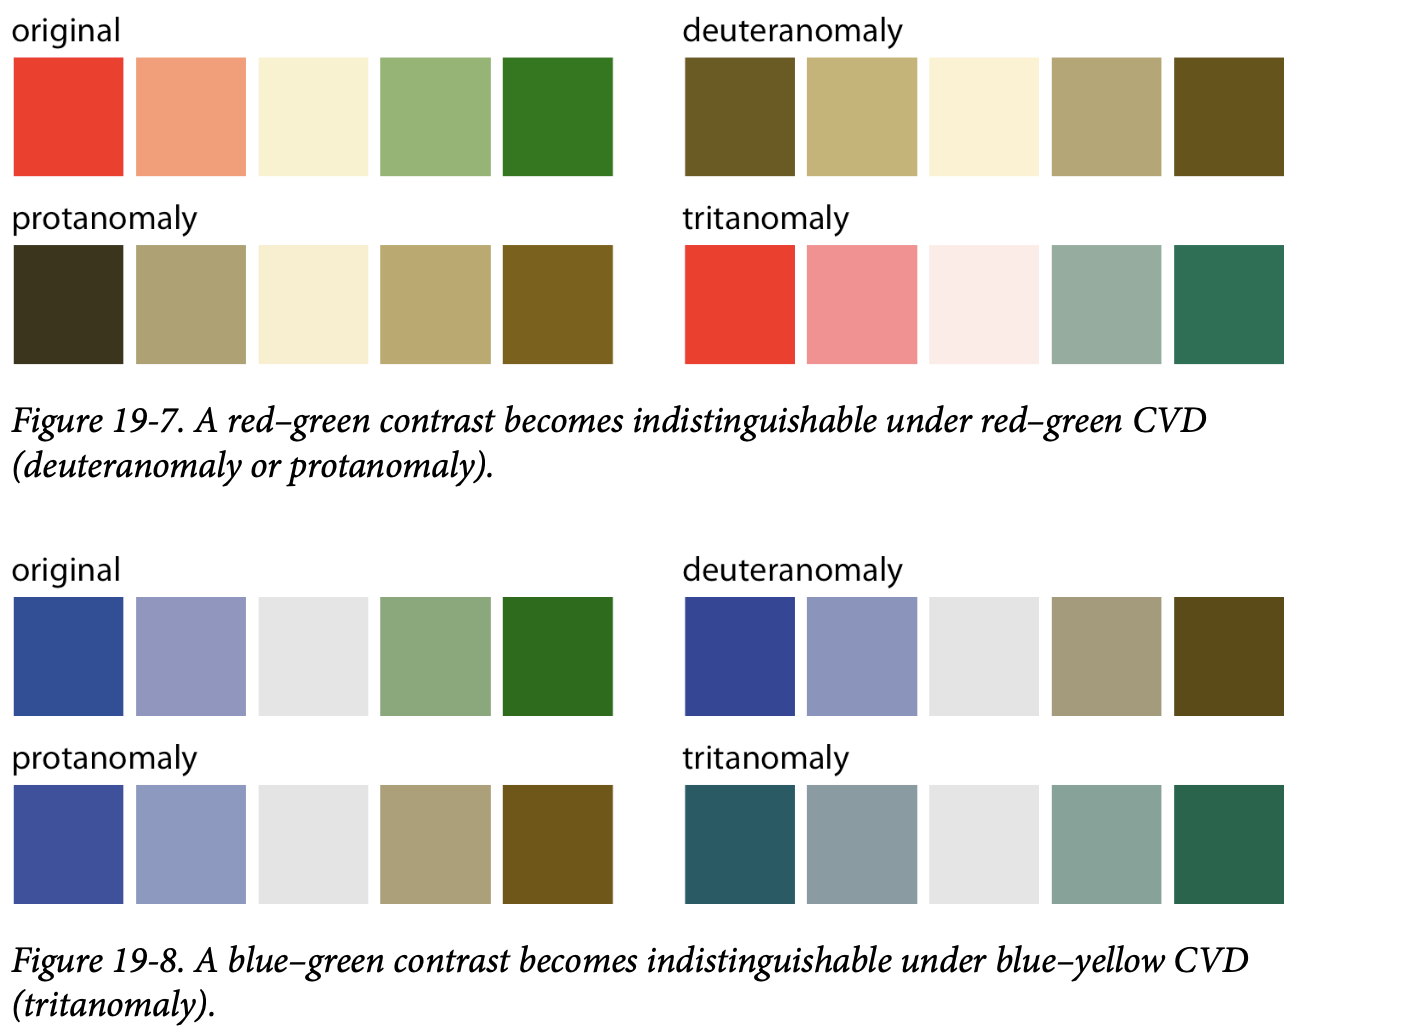

Como recomendación, utilizar la siguiente paleta de colores:

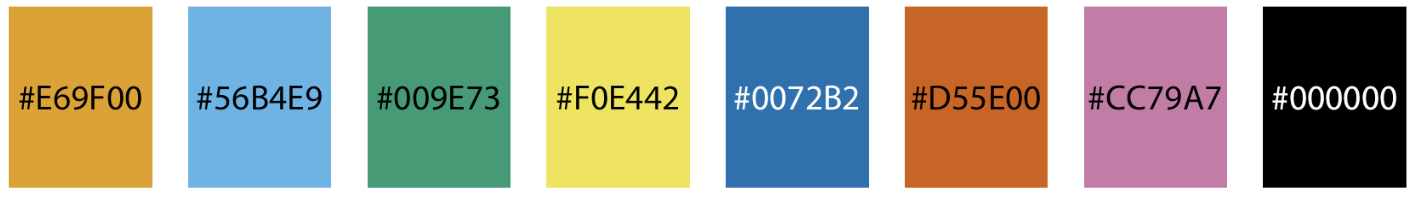

### Forma

Otro parámetro que también nos permitiría incluir una variable es la forma de los puntos.

In [ ]:
# Recordemos el dataset con el que estamos trabajando
df.head()

In [ ]:
fig = px.scatter(df, x="flipper_length_mm", y="body_mass_g", symbol="species")
# .update_traces(marker=dict(size=12), selector=dict(mode='markers'))


fig.show()

Al igual que el color por categoría, los símbolos no permiten distinguir las magnitudes de las variables. 


> **Nota:** `plotly` permite de todas formas combinar colores continuos con símbolos, sin embargo, la leyenda deja de funcionar correctamente. 

In [ ]:
fig = px.scatter(
    df,
    x="flipper_length_mm",
    y="body_mass_g",
    color="culmen_length_mm",
    symbol="species",
    symbol_map={"Adelie": "circle", "Gentoo": "square", "Chinstrap": "star"},
)

fig.update_traces(
    marker=dict(size=12, line=dict(width=2, color="DarkSlateGrey")),
    selector=dict(mode="markers"),
)

fig.show()

La leyenda puede ser modificada usando: 

In [ ]:
fig.update_layout(legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01))
# fig.update_traces(opacity=.8)
fig.show()

> **Pregunta:** ¿Cuántas formas distintas máximas deberían usarse?

Ojalá no más de 4

**Recomendaciones de uso para la forma:**

- Reservar las formas para variables **categóricas** con pocas categorías (≤ 4).
- Las formas son más difíciles de distinguir que los colores; úsalas como elemento **secundario**.
- Combinar formas y colores para la misma variable es *redundante*, pero mejora la **accesibilidad** para personas con daltonismo.
- Evitar formas con variables continuas: no transmiten magnitud.

### Tamaño

El último punto a considerar es el tamaño de cada punto, el cual permite también establecer relación entre las observaciones.

In [ ]:
# Recordemos el dataset con el que estamos trabajando
df.head()

In [ ]:
# pd.cut con etiquetas numéricas devuelve tipo Categorical; se castea a int
# para que plotly lo interprete correctamente como variable numérica en size.
# Usamos una copia para no contaminar df con columnas auxiliares.
df_ = df.copy()
df_["body_mass_g_cat"] = pd.cut(
    df_["body_mass_g"], bins=3, labels=[10, 100, 1000]
).astype(int)

In [ ]:
fig = px.scatter(
    df_,
    x="flipper_length_mm",
    y="culmen_length_mm",
    size="body_mass_g_cat",
    size_max=20,
)

fig.show()

In [ ]:
fig = px.scatter(
    df,
    x="flipper_length_mm",
    y="culmen_length_mm",
    color="island",
    size="body_mass_g",
    size_max=10,
)

fig.show()

### Cierre


Según el artículo original del cual está basado esta clase, el ser humano percibe estos parámetros según el siguiente orden:

1. Posición
2. Tamaño
3. Color
4. Forma

Obviamente ustedes deciden a cual darle más importancia. Lo importante es tener en mente que no por tener muchos elementos la visualización será mejor, si no que **todo debe ser hecho de la forma más sencilla posible, pero no debe ser simple**

## 3.- Usar el Gráfico Correcto para la Tarea por Resolver

Cada tipo de tarea que queramos resolver tiene asociado uno o varios tipo de gráficos que le permitirían visualizar los datos.

Aquí debemos escoger:

1. La herramienta para graficar.
2. La visualización que mejor se ajuste a lo que queremos representar.

### Plotly

`Plotly` es una biblioteca de visualización de datos interactiva que permite crear gráficos y visualizaciones personalizadas de alta calidad en varios lenguajes de programación como Python, R y JavaScript.

En particular, para el curso estaremos usando `Plotly Express`, que es una capa de interfaz de alto nivel que simplifica la creación de gráficos mediante la automatización de muchas de las tareas comunes de visualización y una alta compatibilidad con las herramientas de ciencia de datos como numpy o pandas.


`Plotly express` incluye 30 distintos tipos de gráficos en una interfaz muy unificada y sencilla basada en funciones que usualmente siguen la siguiente sintaxis:


```python
px.{nombre_del_grafico} (
    {df},
    x={variable},
    y={variable_2},
    color={variable_color},
    ... # otras configuraciones
)

```

Cada gráfico cuenta con una extensa documentación. Por ejemplo para generar scatters, buscar en google [`px.scatter`](https://www.google.com/search?q=px.scatter) y ver tanto el manual de usuario como la API asociada.

### Scatter o Gráfico de Dispersión

Representa cada observación como un **punto** en el plano cartesiano, con una variable en el eje X y otra en el eje Y.

**¿Cuándo usarlo?**
- Para explorar la **relación o correlación** entre dos variables numéricas.
- Para detectar **outliers** (puntos fuera del patrón general).
- Como punto de partida del EDA antes de aplicar modelos.

**Detalles interesantes:**
- Admite variables adicionales a través de `color`, `size` y `symbol`.
- Con `trendline="ols"` plotly agrega una regresión lineal automáticamente.
- El parámetro `marginal_x` / `marginal_y` permite añadir histogramas o violins sobre los ejes para ver la distribución de cada variable por separado.
- **Bubble chart**: variante donde `size=` mapea una tercera variable numérica al tamaño de cada punto. Útil para representar tres dimensiones en un scatter plano. Ver el ejemplo en la sección de [Tamaño](#Tamaño).

Todos los detalles en: https://plotly.com/python/line-and-scatter/

In [ ]:
px.scatter(
    df,
    x="flipper_length_mm",
    y="body_mass_g",
    marginal_y="violin",
    marginal_x="histogram",
)

#### Strip Chart

> **Nota:** Un problema de los scatter plot es que dos puntos ubicados en la misma posición serán indistinguibles entre sí (problema conocido como **overplotting**).

El **strip chart** soluciona esto agregando un pequeño desplazamiento aleatorio (*jitter*) a los puntos, dejando visible la densidad en zonas de alta concentración. Es especialmente útil cuando una de las variables es **categórica**.

https://plotly.com/python/strip-charts/

In [ ]:
fig = px.strip(df, x="flipper_length_mm", y="body_mass_g")
fig.show()

### Gráficos de Línea

Conecta observaciones ordenadas (generalmente en el tiempo) con una **línea continua**, mostrando la evolución de una variable.

**¿Cuándo usarlo?**
- Cuando el eje X representa una **variable temporal o secuencial** (años, meses, pasos).
- Para comparar tendencias entre **múltiples grupos o series** a lo largo del tiempo.

**Detalles interesantes:**
- Agregar `markers=True` hace más fácil identificar los valores exactos de cada medición.
- Si las escalas de los grupos son muy distintas (e.g., países con poblaciones muy diferentes), considera usar escala logarítmica con `log_y=True` o normalizar los valores antes de graficar.
- No confundir con scatter: el gráfico de línea *asume* un orden en el eje X, mientras que el scatter no.

In [ ]:
# Gapminder: dataset histórico (1952-2007) con indicadores socioeconómicos
# (esperanza de vida, PIB per cápita y población) para ~140 países del mundo.
px.data.gapminder().head(10)

In [ ]:
df_gapminder = px.data.gapminder()
df_gapminder = df_gapminder[
    df_gapminder.country.isin(
        [
            "Chile",
            "Argentina",
            "Peru",
            "Brazil",
            "Colombia",
            "Mexico",
            "United States",
            "Uruguay",
        ]
    )
]

fig = px.line(
    df_gapminder,
    x="year",
    y="lifeExp",
    color="country",
    markers=True,
    title="Life Expectancy Over Time by Country",
    labels={"lifeExp": "Life Expectancy (years)", "year": "Year"},
)
fig.show()

### Gráfico de Área

Variación del gráfico de línea donde el área bajo la curva está **rellena**, enfatizando la **magnitud acumulada** o el volumen a lo largo del tiempo.

**¿Cuándo usarlo?**
- Para mostrar la **evolución de magnitudes** en el tiempo cuando interesa también el volumen total, no solo la tendencia.
- Para visualizar la **composición proporcional** de un total que cambia en el tiempo con `groupnorm="fraction"` (área 100% apilada).

**Detalles interesantes:**
- Con múltiples series, las áreas se apilan por defecto; esto puede ocultar la evolución individual de cada grupo. Ajustar `line_group` puede ayudar.
- Si las series se superponen mucho y deben compararse individualmente, un gráfico de línea con transparencia (`opacity`) es preferible.
- A diferencia del gráfico de línea, el área introduce un énfasis visual en la magnitud acumulada que puede ser engañoso si no es la métrica de interés.

In [ ]:
fig = px.area(
    df_gapminder,
    x="year",
    y="lifeExp",
    color="country",
    title="Life Expectancy Over Time by Country (Area Chart)",
    labels={"lifeExp": "Life Expectancy (years)", "year": "Year"},
)
fig.show()

### Scatter Matrix (SPLOM)

Genera una **grilla de scatter plots** donde cada celda muestra la relación entre un par de variables. La diagonal suele mostrar la distribución de cada variable individual.

**¿Cuándo usarlo?**
- En la **exploración inicial** de un dataset con varias variables numéricas.
- Para detectar rápidamente qué pares de variables están correlacionados o forman clusters.

**Detalles interesantes:**
- El nombre SPLOM viene de *Scatter PLOt Matrix*.
- Con `color` y `symbol` por categoría, se pueden identificar patrones de separabilidad que son muy útiles antes de aplicar modelos de clasificación.
- Con `diagonal_visible=False` se elimina la diagonal y se gana espacio visual.

> **⚠️ Limitación:** A medida que aumenta el número de variables, la scatter matrix se vuelve progresivamente más difícil de interpretar. Para datasets con muchas columnas, es recomendable seleccionar un **subconjunto de variables relevantes** o considerar alternativas como las coordenadas paralelas.

https://plotly.com/python/splom/

In [ ]:
fig = px.scatter_matrix(
    df,
    # height=600,
    dimensions=[
        "culmen_length_mm",
        "culmen_depth_mm",
        "flipper_length_mm",
        "body_mass_g",
    ],
    symbol="species",
    color="species",
)
fig.show()

### Coordenadas Paralelas

En lugar de usar ejes perpendiculares, dibuja un **eje vertical por cada variable** y conecta cada observación con una línea que pasa por todos los ejes. El patrón de las líneas revela relaciones entre variables.

**¿Cuándo usarlo?**
- Para visualizar **muchas variables numéricas simultáneamente** en un solo gráfico (lo que la scatter matrix no escala bien).
- Para identificar **perfiles de grupos**: observaciones del mismo grupo tendrán líneas con trayectorias similares.

**Detalles interesantes:**
- Es interactivo: se puede **filtrar** arrastrando sobre cada eje para seleccionar rangos.
- Las variables categóricas deben codificarse como números para poder usarlas como color continuo.
- El orden de los ejes puede afectar la interpretación: variables correlacionadas consecutivas generan líneas casi paralelas, lo que facilita su lectura.

In [ ]:
# mapeo de clases a números (usamos copia para no contaminar df con columnas auxiliares)
df_ = df.copy()
df_["species_num"] = df_["species"].map({"Adelie": 0, "Chinstrap": 1, "Gentoo": 2})

fig = px.parallel_coordinates(
    df_,
    color="species_num",
    color_continuous_scale=px.colors.diverging.Tealrose,
    color_continuous_midpoint=1,
)
fig.show()

### Histogramas

Divide el rango de una variable numérica en intervalos (**bins**) y muestra cuántas observaciones caen en cada intervalo. Es la herramienta fundamental para estudiar la **distribución de una variable**.

**¿Cuándo usarlo?**
- Para entender la **forma de la distribución**: ¿es simétrica, sesgada, unimodal, bimodal?
- Para detectar la presencia de **outliers** o valores inusuales.
- Para verificar supuestos de normalidad antes de aplicar ciertos modelos.

**Detalles interesantes:**
- La elección del número de bins (`nbins`) es crítica: muy pocos bins pierden detalle, demasiados generan ruido sin significado.
- Con `histnorm="probability"` el eje Y muestra proporciones en lugar de conteos absolutos, lo que facilita comparar grupos de distinto tamaño.
- Con `marginal="box"` o `marginal="violin"` se puede agregar un boxplot o violin sobre el histograma para ver la distribución desde otro ángulo a la vez.

In [ ]:
fig = px.histogram(df, x="flipper_length_mm")
fig.show()

Un detalle muy importante de los histogramas es cómo se generan las particiones de los rangos de cada barra (también conocidos como **bins**)


Bins muy finos pueden llevar a discontinuidades:

In [ ]:
fig = px.histogram(df, x="flipper_length_mm", nbins=100, histnorm="probability")
fig.show()

Bins muy grandes pueden llevar a distorsionar la información:

In [ ]:
fig = px.histogram(df, x="flipper_length_mm", nbins=5)
fig.show()

Podemos agregar más información a los histogramas a través del color:

In [ ]:
fig = px.histogram(df, x="flipper_length_mm", color="species")
fig.show()

In [ ]:
fig = px.histogram(
    df,
    x="flipper_length_mm",
    barmode="overlay",
    color="species",
)
fig.show()

Hay que ser muy cuidadoso si se le agrega color!
El gráfico anterior es muy complicado de entender. Sería mejor separar por grupos las barras.

In [ ]:
fig = px.histogram(
    df,
    x="flipper_length_mm",
    color="species",
    barmode="group",
)
fig.show()

### Bar Plot

Representa valores numéricos como barras de longitud proporcional, agrupadas por categoría. Es el gráfico estándar para **comparar magnitudes entre grupos**.

**¿Cuándo usarlo?**
- Para comparar un **valor agregado** (suma, promedio, conteo) entre categorías.
- Cuando las categorías son pocas y claramente distinguibles.
- Como alternativa más precisa a los gráficos de torta.

**Detalles interesantes:**
- `barmode="group"` coloca barras lado a lado para comparar subcategorías; `barmode="stack"` las apila para mostrar composición.
- La distinción clave con `px.histogram`:
  - `px.histogram` recibe **datos crudos** y realiza el conteo automáticamente.
  - `px.bar` recibe **datos pre-agregados**, donde cada fila es una barra.
- Las barras deben partir desde 0 salvo justificación explícita; truncar el eje Y puede distorsionar la comparación visual (como vimos en el ejemplo del Principio 1).

> **Nota:** `px.data.medals_wide()` es un dataset de ejemplo incluido directamente en plotly, con datos de medallas olímpicas por país en formato *wide*. Es conveniente para demostrar gráficos de barras apiladas sin necesidad de cargar un archivo externo.

In [ ]:
wide_df = px.data.medals_wide()

fig = px.bar(wide_df, x="nation", y=["gold", "silver", "bronze"], title="Medal Count")
fig.show()

En el ejemplo anterior las barras están **apiladas** (`barmode="stack"`, modo por defecto cuando se pasan múltiples columnas). En el siguiente usamos `barmode="group"` para comparar subcategorías lado a lado:

In [ ]:
df_species_count = df.groupby(["species", "island"]).size().reset_index(name="count")

fig = px.bar(
    df_species_count,
    x="species",
    y="count",
    color="island",
    barmode="group",
    title="Conteo de Pingüinos por Especie e Isla",
    labels={"species": "Especie", "count": "Cantidad", "island": "Isla"},
)
fig.show()

### Torta (Pie Chart)

Representa las **proporciones** de categorías dentro de un todo, usando ángulos de un círculo.

**¿Cuándo usarlo?**
- Solo cuando hay **pocas categorías** (≤ 5) y las diferencias entre ellas son grandes y evidentes.
- Cuando el mensaje central es "X representa aproximadamente la mitad/un tercio del total".

**Detalles interesantes:**
- El ojo humano percibe **ángulos y áreas con menor precisión** que longitudes, lo que hace difícil comparar sectores similares.
- Una variante más expresiva es el **donut chart** (`hole=0.4` en `px.pie`), que reduce el énfasis visual en el área y mejora la legibilidad.
- Para distribuciones con muchas categorías o diferencias pequeñas, un **bar plot ordenado** es siempre preferible.

> **⚠️ Advertencia:** Los gráficos de torta son frecuentemente **desaconsejados** en la literatura de visualización. El ojo humano compara **ángulos** con menor precisión que **longitudes** (como en un gráfico de barras). En la mayoría de los casos, un bar plot es una alternativa más precisa e interpretable.

In [ ]:
df_grouped = (
    df.groupby(["island"])
    .agg({"species": "count"})
    .div(len(df))
    .mul(100)
    .round(2)
    .reset_index()
    .rename(columns={"species": "cantidad"})
)
df_grouped

In [ ]:
fig = px.pie(df_grouped, values="cantidad", names="island")
fig.show()

### Boxplot (Diagrama de Caja)

Resume la distribución de una variable numérica usando **cinco estadísticos**: mínimo, Q1 (percentil 25), mediana (Q2), Q3 (percentil 75) y máximo. Los puntos fuera de los bigotes son **outliers potenciales**.

**¿Cuándo usarlo?**
- Para comparar la distribución de una variable numérica **entre grupos categóricos**.
- Para identificar la **mediana, rango intercuartílico (IQR)** y outliers de forma rápida.
- Cuando hay muchas observaciones y el histograma resulta ruidoso.

**Detalles interesantes:**
- Los "bigotes" (*whiskers*) se extienden hasta 1.5 × IQR desde Q1 y Q3. Todo lo que quede fuera se grafica como punto individual y se considera outlier potencial.
- No revela si la distribución es **bimodal** (dos peaks) — para eso es mejor el violin.
- Se puede combinar con histograma usando `marginal="box"` en `px.histogram`.

In [ ]:
fig = px.histogram(
    df, x="flipper_length_mm", color="species", marginal="box", height=800
)
fig.show()

### Violin

Combina un **boxplot** con una **estimación de densidad de kernel (KDE)**: muestra la forma completa de la distribución como un área simétrica alrededor del eje.

**¿Cuándo usarlo?**
- Cuando quieres ver no solo cuartiles, sino la **forma completa de la distribución** (modas, asimetrías, multimodalidad).
- Para comparar distribuciones entre grupos cuando sospechas diferencias en la forma, no solo en la mediana.

**Detalles interesantes:**
- Con `box=True` se agrega un boxplot interno, combinando ambas representaciones.
- Con `points="all"` se grafican todos los puntos individuales encima del violin, útil cuando el dataset es pequeño.
- Un violin muy delgado en los extremos indica pocos datos en esos rangos; hay que ser cuidadoso con interpretaciones ahí.

In [ ]:
fig = px.violin(df, x="flipper_length_mm", color="species")
fig.show()

### Heatmap (Mapa de Calor)

Representa una **matriz de valores numéricos** usando color: la intensidad del color indica la magnitud de cada celda. Es ideal para visualizar **matrices de correlación, tablas de contingencia o cualquier dato que se organice en una cuadrícula**.

**¿Cuándo usarlo?**
- Para visualizar la **correlación entre variables numéricas** (uso más común en EDA). 
- Para mostrar patrones en datos organizados en filas × columnas (e.g., ventas por producto y mes).
- Para **matrices de confusión** al evaluar modelos de clasificación.

**Detalles interesantes:**
- Usar paletas **divergentes** (e.g., `RdBu_r`) cuando los valores tienen un punto medio significativo (como 0 en correlaciones); paletas **secuenciales** para valores que solo van en una dirección.
- `text_auto=".2f"` agrega el valor numérico dentro de cada celda, imprescindible cuando la matriz es pequeña.
- `zmin=-1, zmax=1` fija los extremos de la escala para que el color neutro siempre represente el 0.

In [ ]:
corr = df.select_dtypes(include="number").corr()

fig = px.imshow(
    corr,
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    title="Heatmap de Correlación — Variables Numéricas de Pingüinos",
)
fig.show()

### Sunburst

Extiende la torta a **múltiples niveles jerárquicos**: el anillo exterior representa subniveles del anillo interior. Es útil para mostrar **estructuras jerárquicas y proporciones anidadas** de forma compacta e interactiva.

**¿Cuándo usarlo?**
- Cuando los datos tienen una **jerarquía** natural (e.g., especie → isla → sexo).
- Para mostrar la composición interna de cada categoría, no solo el total.

**Detalles interesantes:**
- Es interactivo: al hacer clic en un sector se hace **zoom** sobre ese subárbol.
- Una alternativa similar es el **treemap** (`px.treemap`), que usa rectángulos en lugar de ángulos. Las áreas rectangulares son más fáciles de comparar que los arcos, por lo que el treemap suele ser más preciso para detectar diferencias de tamaño.
- El parámetro `path` define la jerarquía como una lista de columnas, de mayor a menor nivel.

In [ ]:
fig = px.sunburst(
    df,
    path=["species", "island", "sex"],
    title="Composición de Pingüinos: Especie → Isla → Sexo",
)
fig.show()

Otros gráficos disponibles en plotly que vale explorar:

- **Coroplético** (`px.choropleth`): colorea regiones de un mapa según el valor de una variable. Ideal para datos geográficos.
- **Density heatmap** (`px.density_heatmap`): variante del scatter que muestra densidad de puntos con color, útil para grandes volúmenes de datos.
- **Funnel** (`px.funnel`): visualiza etapas de un proceso y cuántos casos pasan de una a otra.
- Y muchas más en https://plotly.com/python/

---

## 4.- La Tinta es Barata, los Electrones Aún Más

El último se refiere al hecho de que no es necesario intentar incluir todos los aspectos que se quiera analizar en un solo gráfico, si no que por el contrario, podemos crear múltiples gráficos con distintos grupos por analizar sin mayores problemas. En términos prácticos, el separar un gráfico implica una ventaja inesperada: incluir una nueva variable al análisis también conocida como el grupo de separación.

> La Tinta es Barata, los Electrones Aún Más -> Hace más de un gráfico!

El siguiente ejemplo muestra como podemos hacer un análisis diferenciado por especie del peso y el tamaño de la aleta.

In [ ]:
# Recordemos el dataset con el que estamos trabajando
df.head()

In [ ]:
fig = px.scatter(df, x="flipper_length_mm", y="body_mass_g", color="culmen_length_mm")
fig.show()

#### Facets (Small Multiples)

Los **facets** dividen un gráfico en subgráficos, uno por categoría, compartiendo los mismos ejes. En plotly se controlan con:

- `facet_col="variable"`: genera una **columna** por cada valor de la variable.
- `facet_row="variable"`: genera una **fila** por cada valor de la variable.

**¿Cuándo usarlos?**
- Cuando el canal `color` ya está ocupado por otra variable y necesitamos codificar una categoría adicional.
- Para comparar el mismo patrón en distintos subgrupos sin sobrecargar un único gráfico.

**Detalle:** Usar `facet_col` + `facet_row` simultáneamente codifica **dos variables categóricas adicionales** en un solo gráfico, resultando en una cuadrícula de subgráficos.

In [ ]:
fig = px.scatter(
    df,
    x="flipper_length_mm",
    y="body_mass_g",
    color="culmen_length_mm",
    facet_col="species",
    facet_row="sex",
    height=800,
)

fig.show()

### Extra: Templates y Recorrido por la Documentación


https://plotly.com/python/templates/

In [ ]:
fig = px.scatter(
    df,
    x="flipper_length_mm",
    y="body_mass_g",
    color="body_mass_g",
    facet_col="species",
    template="simple_white",
)

fig.show()

---

## 5.- Análisis Exploratorio de Datos (EDA)

El **Análisis Exploratorio de Datos** (EDA, por sus siglas en inglés) es el proceso de examinar sistemáticamente un dataset **antes** de aplicar modelos o extraer conclusiones. Su objetivo es **entender la estructura de los datos**, detectar patrones, identificar anomalías y verificar supuestos.

En términos prácticos, el EDA responde preguntas como:

- ¿Cuántas observaciones y variables tiene el dataset?
- ¿Qué tipos de datos hay?
- ¿Existen valores faltantes?
- ¿Cómo se distribuyen las variables?
- ¿Hay correlaciones entre variables?

¡Todo lo aprendido sobre visualización en esta clase es una herramienta fundamental para el EDA!

### 5.1 Vista General del Dataset

> **Pregunta ❓**: Antes de explorar los datos, ¿qué información básica querrías conocer de un dataset nuevo?

In [ ]:
print(f"Shape: {df.shape}")
print(f"\nTipos de datos:")
print(df.dtypes)

In [ ]:
df.info()

In [ ]:
df.describe()

> **Pregunta ❓**: ¿Qué información entrega `.describe()`? ¿De qué manera podría ayudarnos a detectar anomalías o errores en los datos?

#### Ubicación Geográfica

Antes de entrar al análisis estadístico, es útil visualizar **de dónde provienen los datos**. Los pingüinos fueron recolectados en tres islas del Archipiélago de Palmer, en la Antártica.

In [ ]:
# Coordenadas aproximadas de cada isla en el Archipiélago de Palmer, Antártica
# Fuente: Gorman et al. (2014)
island_coords = {
    "Biscoe": {"lat": -64.82, "lon": -63.78},  # Biscoe Point, Isla Anvers
    "Dream": {"lat": -64.72, "lon": -64.23},
    "Torgersen": {"lat": -64.77, "lon": -64.08},
}

df_map = df.groupby(["island", "species"]).size().reset_index(name="count")
df_map["lat"] = df_map["island"].map({k: v["lat"] for k, v in island_coords.items()})
df_map["lon"] = df_map["island"].map({k: v["lon"] for k, v in island_coords.items()})

fig = px.scatter_geo(
    df_map,
    lat="lat",
    lon="lon",
    color="island",
    size="count",
    hover_name="island",
    hover_data={"species": True, "count": True, "lat": False, "lon": False},
    title="Distribución de Pingüinos por Isla (Archipiélago de Palmer, Antártica)",
    projection="natural earth",
)
fig.update_geos(
    fitbounds="locations",
    resolution=50,
    showland=True,
    landcolor="lightgray",
    showocean=True,
    oceancolor="lightblue",
)
fig.show()


---

### 5.2 Valores Faltantes

Una de las primeras inspecciones que debemos hacer es verificar si existen **valores faltantes** en el dataset. Su presencia puede afectar significativamente el análisis y los modelos posteriores.

In [ ]:
# Cargamos el dataset sin limpiar para visualizar los valores faltantes
df_raw = pd.read_csv(
    "https://raw.githubusercontent.com/MDS7202/MDS7202/main/recursos/2023-01/12-Visualizaciones/penguins.csv"
)
print("Valores faltantes por columna:")
print(df_raw.isnull().sum())
print(
    f"\nTotal: {df_raw.isnull().sum().sum()} valores faltantes en el dataset original"
)

In [ ]:
# Mapa de calor de valores faltantes: rojo = faltante, blanco = presente
fig = px.imshow(
    df_raw.isnull().astype(int),
    color_continuous_scale=["white", "#EF553B"],
    title="Mapa de Valores Faltantes",
    labels=dict(color="Faltante"),
    aspect="auto",
)
fig.update_coloraxes(showscale=False)
fig.show()

> **Nota:** Usamos `df_raw` (sin limpiar) para detectar los valores faltantes. El dataset de trabajo `df` fue previamente limpiado con `df.dropna()`. En datasets del mundo real, los valores faltantes son muy comunes y deben tratarse con cuidado (imputación, eliminación, etc.).

---

### 5.3 Análisis Univariado

El análisis univariado estudia cada **variable por separado**. Permite entender su distribución, detectar outliers y conocer sus valores más frecuentes.

> **Pregunta ❓**: ¿Cuál es la diferencia entre analizar una variable numérica y una variable categórica?

In [ ]:
# Distribución de una variable numérica
fig = px.histogram(
    df,
    x="flipper_length_mm",
    nbins=20,
    title="Distribution of Flipper Length",
    labels={"flipper_length_mm": "Flipper Length (mm)"},
)
fig.show()

In [ ]:
# Conteo de frecuencias para variables categóricas
fig = px.histogram(
    df,
    x="species",
    color="species",
    title="Species Count",
    labels={"species": "Species"},
)
fig.show()

> **Pregunta ❓**: ¿El dataset está balanceado entre las tres especies de pingüinos? ¿Podría esto afectar un análisis posterior?

---

### 5.4 Análisis Bivariado

El análisis bivariado estudia la **relación entre dos variables**. Una herramienta clave es la **matriz de correlación**, que mide la correlación lineal entre variables numéricas.

In [ ]:
# Matriz de correlación entre variables numéricas
corr_matrix = df.select_dtypes(include="number").corr()

fig = px.imshow(
    corr_matrix,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    title="Correlation Matrix",
)
fig.show()

> **Pregunta ❓**: ¿Qué pares de variables presentan mayor correlación? ¿Tiene sentido biológico esta relación?

In [ ]:
# Relación entre culmen_length y culmen_depth, segmentada por especie
fig = px.scatter(
    df,
    x="culmen_length_mm",
    y="culmen_depth_mm",
    color="species",
    trendline="ols",
    title="Culmen Length vs. Culmen Depth by Species",
    labels={
        "culmen_length_mm": "Culmen Length (mm)",
        "culmen_depth_mm": "Culmen Depth (mm)",
    },
)
fig.show()

> **Nota:** Este gráfico ilustra la [**Paradoja de Simpson**](https://es.wikipedia.org/wiki/Paradoja_de_Simpson): al analizar todas las especies juntas, la relación parece *negativa*, pero al separarlas por especie, la relación es *positiva* para cada una. ¡Una razón más para siempre segmentar y explorar los datos!

---

#### Relación Numérica-Categórica

Otro tipo de análisis bivariado clave es estudiar cómo se distribuyen las variables **numéricas según categorías**. Para esto se usan boxplots y violins, tipos de gráficos que ya vimos anteriormente y que aquí aplicamos directamente al EDA.

> **Pregunta ❓**: ¿Qué variable numérica y qué variable categórica crees que mostrarían la diferencia más marcada entre grupos?

In [ ]:
# Boxplot: distribución de masa corporal por especie
fig = px.box(
    df,
    x="species",
    y="body_mass_g",
    color="species",
    title="Distribución de Masa Corporal por Especie",
    labels={"species": "Especie", "body_mass_g": "Masa corporal (g)"},
)
fig.show()

In [ ]:
# Violin: largo de aleta por especie y sexo — muestra la forma completa de la distribución
fig = px.violin(
    df,
    x="species",
    y="flipper_length_mm",
    color="sex",
    box=True,
    points="all",
    title="Largo de Aleta por Especie y Sexo",
    labels={
        "species": "Especie",
        "flipper_length_mm": "Largo de aleta (mm)",
        "sex": "Sexo",
    },
)
fig.show()

---

### 5.5 Análisis Multivariado

El análisis **multivariado** estudia la relación entre **más de dos variables simultáneamente**. Ya vimos dos herramientas poderosas para esto: la scatter matrix y las coordenadas paralelas. Aquí las aplicamos directamente al EDA para obtener una visión global del dataset.

In [ ]:
# Scatter matrix: relación entre todas las variables numéricas, coloreadas por especie
fig = px.scatter_matrix(
    df,
    dimensions=[
        "culmen_length_mm",
        "culmen_depth_mm",
        "flipper_length_mm",
        "body_mass_g",
    ],
    color="species",
    symbol="species",
    title="Scatter Matrix — Relación entre Variables Numéricas por Especie",
)
fig.update_traces(diagonal_visible=False)
fig.show()

---

### 5.6 EDA Rápido con `ydata_profiling`

Hacer un EDA completo de forma manual puede ser tedioso. La librería [`ydata_profiling`](https://github.com/ydataai/ydata-profiling) (anteriormente `pandas_profiling`) permite generar un **reporte interactivo completo** con pocas líneas de código.

El reporte incluye automáticamente:
- Estadísticas descriptivas por variable
- Distribuciones y detección de outliers
- Matriz de correlaciones
- Análisis de valores faltantes
- Alertas sobre posibles problemas en los datos

In [ ]:
!uv pip install ydata-profiling setuptools

In [ ]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Penguins Dataset EDA", explorative=True)
profile.to_notebook_iframe()

> **⚠️ Advertencia:** `ydata_profiling` puede ser **lento** con datasets grandes (muchas columnas o millones de filas). Es una excelente herramienta para la **exploración inicial**, pero no reemplaza el análisis manual ni el criterio del analista.

---

## Conclusión

En esta clase estudiamos los cuatro principios fundamentales para crear buenas visualizaciones de datos y los aplicamos en un flujo de Análisis Exploratorio de Datos (EDA).

### Los cuatro principios

1. **Un buen gráfico cuenta una historia**: La diferencia entre un gráfico *exploratorio* (identificar patrones) y uno *explicativo* (comunicar hallazgos) es la presencia de una interpretación explícita de los patrones detectados.

2. **Todo debe ser hecho de la forma más sencilla posible, pero no debe ser simple**: Los *aesthetics* (posición, color, forma y tamaño) permiten enriquecer la visualización, pero siempre priorizando la claridad. El ser humano percibe estos elementos en el siguiente orden de efectividad: **posición > tamaño > color > forma**.

3. **Se debe usar la herramienta correcta para el trabajo a resolver**: Cada tipo de pregunta o dato tiene un gráfico más adecuado: scatter, histograma, barras, violin, boxplot, scatter matrix, etc. Conocer las opciones disponibles es clave.

4. **La tinta es barata, los electrones aún más**: No es necesario incluir todo en un solo gráfico. Crear múltiples gráficos segmentados (`facet_col`, `facet_row`) añade dimensiones de análisis sin sacrificar claridad.

### EDA

El **EDA** utiliza todas estas herramientas para comprender un dataset antes de modelar o tomar decisiones:

- **Vista general** (5.1): forma, tipos de datos, estadísticas descriptivas y ubicación geográfica de los datos.
- **Valores faltantes** (5.2): visualizados con mapas de calor antes de aplicar cualquier limpieza.
- **Análisis univariado** (5.3): histogramas y conteos de frecuencia por variable.
- **Análisis bivariado** (5.4): correlaciones numéricas (con atención a la Paradoja de Simpson) y relaciones numérico-categóricas (boxplot, violin).
- **Análisis multivariado** (5.5): scatter matrix para visualizar todas las relaciones simultáneamente.
- **EDA automatizado** (5.6): `ydata_profiling` acelera la exploración inicial, pero el juicio analítico sigue siendo irreemplazable.